In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn import metrics
from sklearn import preprocessing
import pickle

In [2]:
scaler = preprocessing.MinMaxScaler()

In [3]:
data=pd.read_csv('out time separated 2.csv')
data=data.sample(frac=1)
data = data[data['Successful_Read'] == True]
data = data[data['Shape'] == 'kare']
data.head()

,Unnamed: 0,Gas_Type,CH4,Ar,N2,CO2,C,O,H,Shape,...,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count,Folder,Successful_Read
66878,66878,p20,0.2,0.8,0.0,0.0,0.04,0.0,0.16,kare,...,45.97,4.78,22.85,0.50,8000,kaynaksız,1,156,"detektor data 2/P20/Kare/Kare 6,78X6,78/4,78x4...",True
10759,10759,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,...,100.00,4.00,16.00,0.16,7000,kaynaksız,3,22,detektor data 2/P10/Kare/Kare 10x10/4x4/p10 70...,True
23696,23696,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,...,45.97,6.68,44.62,0.97,4000,kaynaksız,1,1,"detektor data 2/P10/Kare/Kare 6,78X6,78/6,68x6...",True
58519,58519,p20,0.2,0.8,0.0,0.0,0.04,0.0,0.16,kare,...,100.00,8.00,64.00,0.64,7000,kaynaksız,10,15,detektor data 2/P20/Kare/Kare 10x10/8x8/7000V ...,True
16543,16543,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,...,100.00,8.00,64.00,0.64,2500,kaynaksız,1,0,detektor data 2/P10/Kare/Kare 10x10/8x8/p10 25...,True


In [4]:
data=data.sample(frac=1)
#data= data[data['Detector_Size'] == 10]
#data.drop(['Unnamed: 0','Shape','Detector_Size','Cover_Size','CH4','CO2'],axis=1,inplace=True)
#data= data.set_index('Event')


#data= data[data['Gas_Type'] != 'p10']
data.drop(['Shape','Folder','Successful_Read'],axis=1,inplace=True)


data = data[data['Time_Window'].isin([15])]
#data.drop(['Time_Window'],axis=1,inplace=True)



#data= data[(data['Voltage'] >= 4500) & (data['Voltage'] <= 5500)]
#data= data[data['Detector_Size'] == 10]

#data.drop(['Voltage'],axis=1,inplace=True)


In [5]:
#groupByData = data.groupby(['Gas_Type', 'Detector_Size','Cover_Size','Voltage','Time_Window','Source'])

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2456 entries, 91808 to 3055
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        2456 non-null   int64  
 1   Gas_Type          2456 non-null   object 
 2   CH4               2456 non-null   float64
 3   Ar                2456 non-null   float64
 4   N2                2456 non-null   float64
 5   CO2               2456 non-null   float64
 6   C                 2456 non-null   float64
 7   O                 2456 non-null   float64
 8   H                 2456 non-null   float64
 9   Detector_Size     2456 non-null   float64
 10  Detector_Area     2456 non-null   float64
 11  Cover_Size        2456 non-null   float64
 12  Cover_Area        2456 non-null   float64
 13  Cover_Area_Ratio  2456 non-null   float64
 14  Voltage           2456 non-null   int64  
 15  Source            2456 non-null   object 
 16  Time_Window       2456 non-null   int64  
 

In [7]:
data.isnull()

,Unnamed: 0,Gas_Type,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count
91808,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
61123,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
464,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
10127,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
83785,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63009,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9893,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
57346,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
60177,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
data.isnull().sum()

Unnamed: 0          0
Gas_Type            0
CH4                 0
Ar                  0
N2                  0
CO2                 0
C                   0
O                   0
H                   0
Detector_Size       0
Detector_Area       0
Cover_Size          0
Cover_Area          0
Cover_Area_Ratio    0
Voltage             0
Source              0
Time_Window         0
Peak_Count          0
dtype: int64

<Axes: >

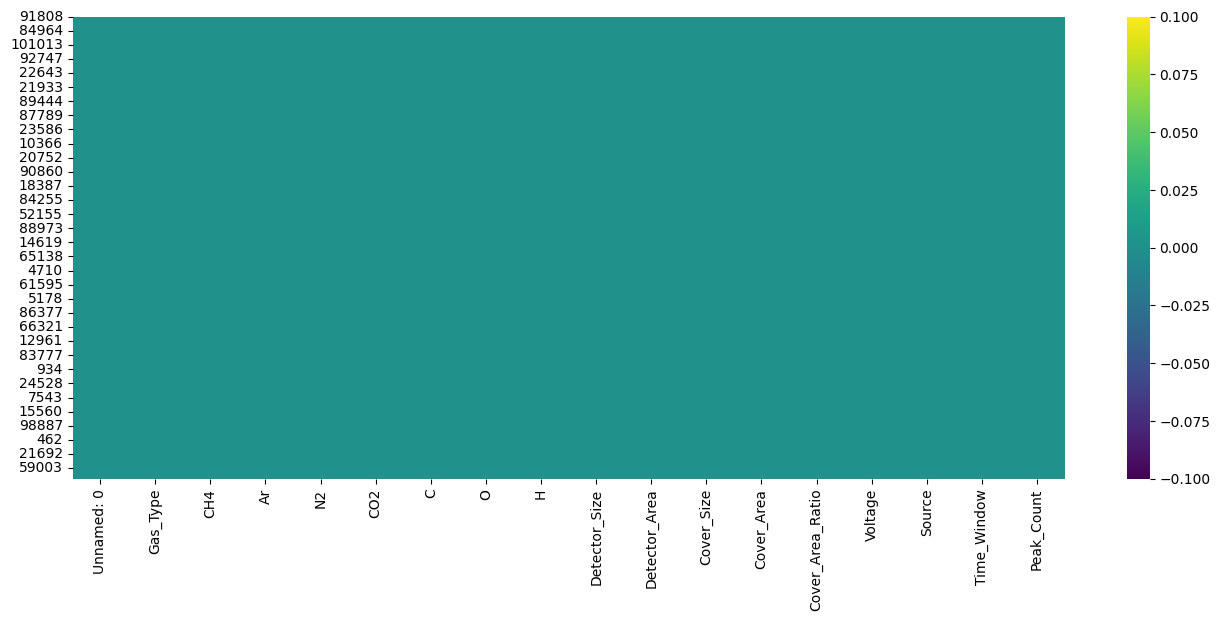

In [9]:
plt.figure(figsize=(16, 6))
sns.heatmap(data.isnull(),cmap='viridis')

In [10]:
data.dropna(inplace=True)

In [11]:
data.isnull().sum()

Unnamed: 0          0
Gas_Type            0
CH4                 0
Ar                  0
N2                  0
CO2                 0
C                   0
O                   0
H                   0
Detector_Size       0
Detector_Area       0
Cover_Size          0
Cover_Area          0
Cover_Area_Ratio    0
Voltage             0
Source              0
Time_Window         0
Peak_Count          0
dtype: int64

In [12]:
data.head()

,Unnamed: 0,Gas_Type,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count
91808,91808,arnco2,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.0,100.0,8.0,64.0,0.64,7000,cs,15,11
61123,61123,p20,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.0,100.0,8.0,64.0,0.64,8000,kaynaksız,15,39
464,464,p10,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.0,100.0,6.0,36.0,0.36,7500,cs,15,110
10127,10127,p10,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.0,100.0,4.0,16.0,0.16,7500,kaynaksız,15,137
83785,83785,arnco2,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.0,100.0,6.0,36.0,0.36,4000,kaynaksız,15,0


In [13]:
type2=pd.get_dummies(data['Gas_Type'],dtype=float)
type2

,arnco2,p10,p20
91808,1.0,0.0,0.0
61123,0.0,0.0,1.0
464,0.0,1.0,0.0
10127,0.0,1.0,0.0
83785,1.0,0.0,0.0
...,...,...,...
63009,0.0,0.0,1.0
9893,0.0,1.0,0.0
57346,0.0,0.0,1.0
60177,0.0,0.0,1.0


In [14]:
type=pd.get_dummies(data['Source'],dtype=float)
type

,cs,kaynaksız
91808,1.0,0.0
61123,0.0,1.0
464,1.0,0.0
10127,0.0,1.0
83785,0.0,1.0
...,...,...
63009,0.0,1.0
9893,1.0,0.0
57346,0.0,1.0
60177,1.0,0.0


In [15]:
data['KV2'] = (data['Voltage']/1000)**2
data.head()

,Unnamed: 0,Gas_Type,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count,KV2
91808,91808,arnco2,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.0,100.0,8.0,64.0,0.64,7000,cs,15,11,49.00
61123,61123,p20,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.0,100.0,8.0,64.0,0.64,8000,kaynaksız,15,39,64.00
464,464,p10,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.0,100.0,6.0,36.0,0.36,7500,cs,15,110,56.25
10127,10127,p10,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.0,100.0,4.0,16.0,0.16,7500,kaynaksız,15,137,56.25
83785,83785,arnco2,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.0,100.0,6.0,36.0,0.36,4000,kaynaksız,15,0,16.00


In [16]:
data=pd.concat([data,type2,type],axis=1)
data.head()

,Unnamed: 0,Gas_Type,CH4,Ar,N2,CO2,C,O,H,Detector_Size,...,Voltage,Source,Time_Window,Peak_Count,KV2,arnco2,p10,p20,cs,kaynaksız
91808,91808,arnco2,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.0,...,7000,cs,15,11,49.00,1.0,0.0,0.0,1.0,0.0
61123,61123,p20,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.0,...,8000,kaynaksız,15,39,64.00,0.0,0.0,1.0,0.0,1.0
464,464,p10,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.0,...,7500,cs,15,110,56.25,0.0,1.0,0.0,1.0,0.0
10127,10127,p10,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.0,...,7500,kaynaksız,15,137,56.25,0.0,1.0,0.0,0.0,1.0
83785,83785,arnco2,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.0,...,4000,kaynaksız,15,0,16.00,1.0,0.0,0.0,0.0,1.0


In [17]:
#sns.set(style="ticks", color_codes=True)
#g = sns.pairplot(data)
#plt.show()

In [18]:
data.drop(['Source','kaynaksız','Gas_Type','Unnamed: 0'],axis=1,inplace=True)
#data.drop(['CH4','Ar','N2','CO2','C','O','H'],axis=1,inplace=True)
data.drop(['p10','p20','arnco2'],axis=1,inplace=True)


data.head()

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Time_Window,Peak_Count,KV2,cs
91808,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.0,100.0,8.0,64.0,0.64,7000,15,11,49.00,1.0
61123,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.0,100.0,8.0,64.0,0.64,8000,15,39,64.00,0.0
464,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.0,100.0,6.0,36.0,0.36,7500,15,110,56.25,1.0
10127,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.0,100.0,4.0,16.0,0.16,7500,15,137,56.25,0.0
83785,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.0,100.0,6.0,36.0,0.36,4000,15,0,16.00,0.0


In [19]:
names = data.columns

In [20]:
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 2456 entries, 91808 to 3055
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CH4               2456 non-null   float64
 1   Ar                2456 non-null   float64
 2   N2                2456 non-null   float64
 3   CO2               2456 non-null   float64
 4   C                 2456 non-null   float64
 5   O                 2456 non-null   float64
 6   H                 2456 non-null   float64
 7   Detector_Size     2456 non-null   float64
 8   Detector_Area     2456 non-null   float64
 9   Cover_Size        2456 non-null   float64
 10  Cover_Area        2456 non-null   float64
 11  Cover_Area_Ratio  2456 non-null   float64
 12  Voltage           2456 non-null   int64  
 13  Time_Window       2456 non-null   int64  
 14  Peak_Count        2456 non-null   int64  
 15  KV2               2456 non-null   float64
 16  cs                2456 non-null   float64
d

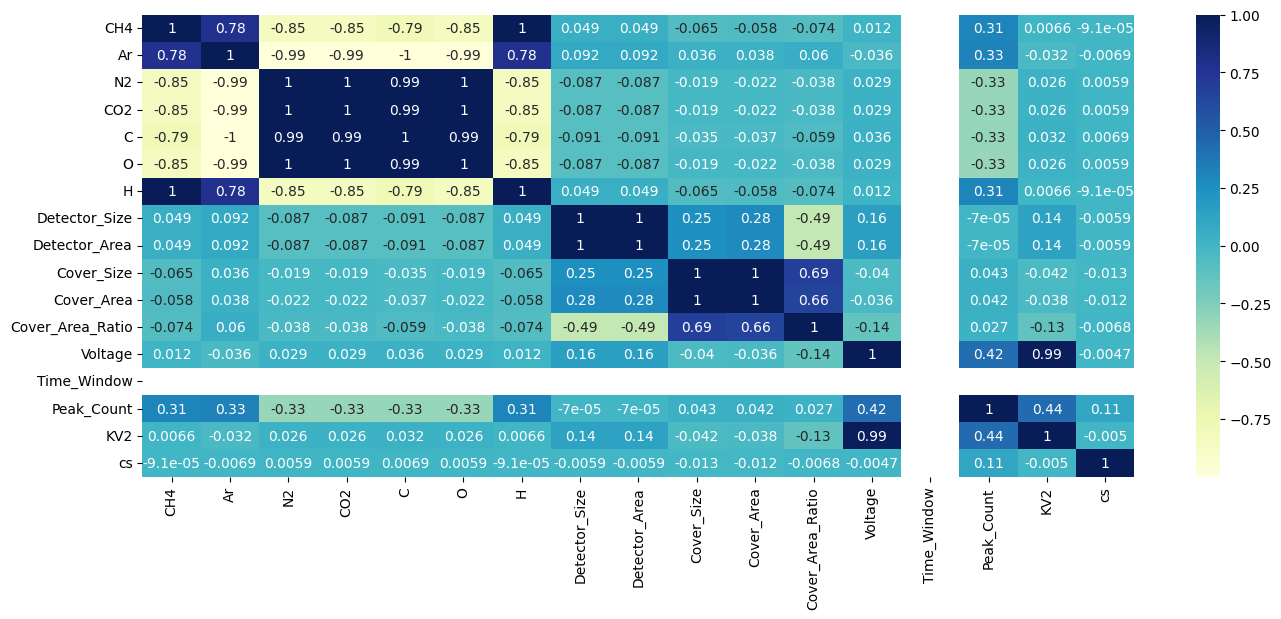

In [21]:
# creation of correlation matrix
corrM = data.corr()
plt.figure(figsize=(16, 6))
dataplot = sns.heatmap(corrM, cmap="YlGnBu", annot=True) 


In [22]:
corr = corrM[abs(corrM['Peak_Count'])>0.1][['Peak_Count']]
list(corr.index)

['CH4', 'Ar', 'N2', 'CO2', 'C', 'O', 'H', 'Voltage', 'Peak_Count', 'KV2', 'cs']

In [23]:
#data=data[list(corr.index)]
data

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Time_Window,Peak_Count,KV2,cs
91808,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.0,100.0,8.0,64.0,0.64,7000,15,11,49.00,1.0
61123,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.0,100.0,8.0,64.0,0.64,8000,15,39,64.00,0.0
464,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.0,100.0,6.0,36.0,0.36,7500,15,110,56.25,1.0
10127,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.0,100.0,4.0,16.0,0.16,7500,15,137,56.25,0.0
83785,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.0,100.0,6.0,36.0,0.36,4000,15,0,16.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63009,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.0,100.0,8.0,64.0,0.64,6000,15,231,36.00,0.0
9893,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.0,100.0,4.0,16.0,0.16,5500,15,134,30.25,1.0
57346,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.0,100.0,4.0,16.0,0.16,6000,15,68,36.00,0.0
60177,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.0,100.0,8.0,64.0,0.64,4500,15,108,20.25,1.0


In [24]:
from sklearn.model_selection import train_test_split

In [25]:
data[['Time_Window','Peak_Count','Voltage']] = data[['Time_Window','Peak_Count','Voltage']].astype('float')
data['Peak_Count'] = np.sqrt(data['Peak_Count'])


x=data.drop(['Peak_Count'],axis=1)

x.head()

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Time_Window,KV2,cs
91808,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.0,100.0,8.0,64.0,0.64,7000.0,15.0,49.00,1.0
61123,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.0,100.0,8.0,64.0,0.64,8000.0,15.0,64.00,0.0
464,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.0,100.0,6.0,36.0,0.36,7500.0,15.0,56.25,1.0
10127,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.0,100.0,4.0,16.0,0.16,7500.0,15.0,56.25,0.0
83785,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.0,100.0,6.0,36.0,0.36,4000.0,15.0,16.00,0.0


In [26]:
y=data['Peak_Count']
y

91808     3.316625
61123     6.244998
464      10.488088
10127    11.704700
83785     0.000000
           ...    
63009    15.198684
9893     11.575837
57346     8.246211
60177    10.392305
3055      4.358899
Name: Peak_Count, Length: 2456, dtype: float64

In [27]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [28]:
scalerModel = scaler.fit(X_train)
X_train = scalerModel.transform(X_train)
X_test = scalerModel.transform(X_test)

In [29]:
from sklearn.linear_model import LinearRegression

In [30]:
model=LinearRegression()

In [31]:
model.fit(X_train,y_train)

LinearRegression()

In [32]:
pred=model.predict(X_test)
pred

array([ 4.03515625e+00,  1.06445312e+01,  4.44531250e+00,  5.61914062e+00,
        7.91406250e+00,  1.13750000e+01,  1.09550781e+01,  1.05410156e+01,
        3.00781250e+00,  1.24707031e+01,  5.34960938e+00,  1.90429688e+00,
        1.30332031e+01, -6.79687500e-01,  9.42187500e+00, -2.38671875e+00,
        1.07246094e+01,  9.84960938e+00,  1.42578125e-01,  2.43750000e+00,
        9.47656250e+00,  3.54687500e+00,  1.42558594e+01,  8.08007812e+00,
        9.40820312e+00,  1.35703125e+01,  1.05781250e+01,  1.46503906e+01,
        1.17929688e+01,  1.61484375e+01,  6.01367188e+00,  4.00390625e+00,
        7.65039062e+00,  1.58164062e+01, -8.20117188e+00,  1.13750000e+01,
        3.00781250e+00,  1.72812500e+01,  5.83007812e+00,  4.35546875e-01,
        1.23671875e+01,  8.77929688e+00,  1.19531250e+01,  6.18750000e+00,
        1.05410156e+01,  6.75195312e+00,  3.10937500e+00,  6.82812500e+00,
        6.73437500e+00,  1.21289062e+01,  6.01367188e+00,  3.45312500e+00,
        1.47695312e+01,  

In [33]:
y_test

16268     0.000000
5415      5.385165
90155     1.000000
91571     1.000000
23343     8.831761
           ...    
17214    15.779734
54046    15.329710
13435    18.083141
5654      9.165151
13197    15.811388
Name: Peak_Count, Length: 492, dtype: float64

In [34]:
X_test

array([[0.5       , 1.        , 0.        , ..., 0.        , 0.        ,
        1.        ],
       [0.5       , 1.        , 0.        , ..., 0.        , 0.4375    ,
        0.        ],
       [0.        , 0.        , 1.        , ..., 0.        , 0.53333333,
        1.        ],
       ...,
       [0.5       , 1.        , 0.        , ..., 0.        , 0.4375    ,
        1.        ],
       [0.5       , 1.        , 0.        , ..., 0.        , 0.27083333,
        1.        ],
       [0.5       , 1.        , 0.        , ..., 0.        , 0.87083333,
        1.        ]])

In [35]:
model.score(X_test, y_test)

0.6184729364115542

In [36]:
pred

array([ 4.03515625e+00,  1.06445312e+01,  4.44531250e+00,  5.61914062e+00,
        7.91406250e+00,  1.13750000e+01,  1.09550781e+01,  1.05410156e+01,
        3.00781250e+00,  1.24707031e+01,  5.34960938e+00,  1.90429688e+00,
        1.30332031e+01, -6.79687500e-01,  9.42187500e+00, -2.38671875e+00,
        1.07246094e+01,  9.84960938e+00,  1.42578125e-01,  2.43750000e+00,
        9.47656250e+00,  3.54687500e+00,  1.42558594e+01,  8.08007812e+00,
        9.40820312e+00,  1.35703125e+01,  1.05781250e+01,  1.46503906e+01,
        1.17929688e+01,  1.61484375e+01,  6.01367188e+00,  4.00390625e+00,
        7.65039062e+00,  1.58164062e+01, -8.20117188e+00,  1.13750000e+01,
        3.00781250e+00,  1.72812500e+01,  5.83007812e+00,  4.35546875e-01,
        1.23671875e+01,  8.77929688e+00,  1.19531250e+01,  6.18750000e+00,
        1.05410156e+01,  6.75195312e+00,  3.10937500e+00,  6.82812500e+00,
        6.73437500e+00,  1.21289062e+01,  6.01367188e+00,  3.45312500e+00,
        1.47695312e+01,  

In [37]:
y_test

16268     0.000000
5415      5.385165
90155     1.000000
91571     1.000000
23343     8.831761
           ...    
17214    15.779734
54046    15.329710
13435    18.083141
5654      9.165151
13197    15.811388
Name: Peak_Count, Length: 492, dtype: float64

In [38]:
#indexes = X_test.index.values
#index=indexes[98]

In [39]:
#X_test.loc[index]

In [40]:
#y_test[index],pred[98]
pred[pred<=0] = 0

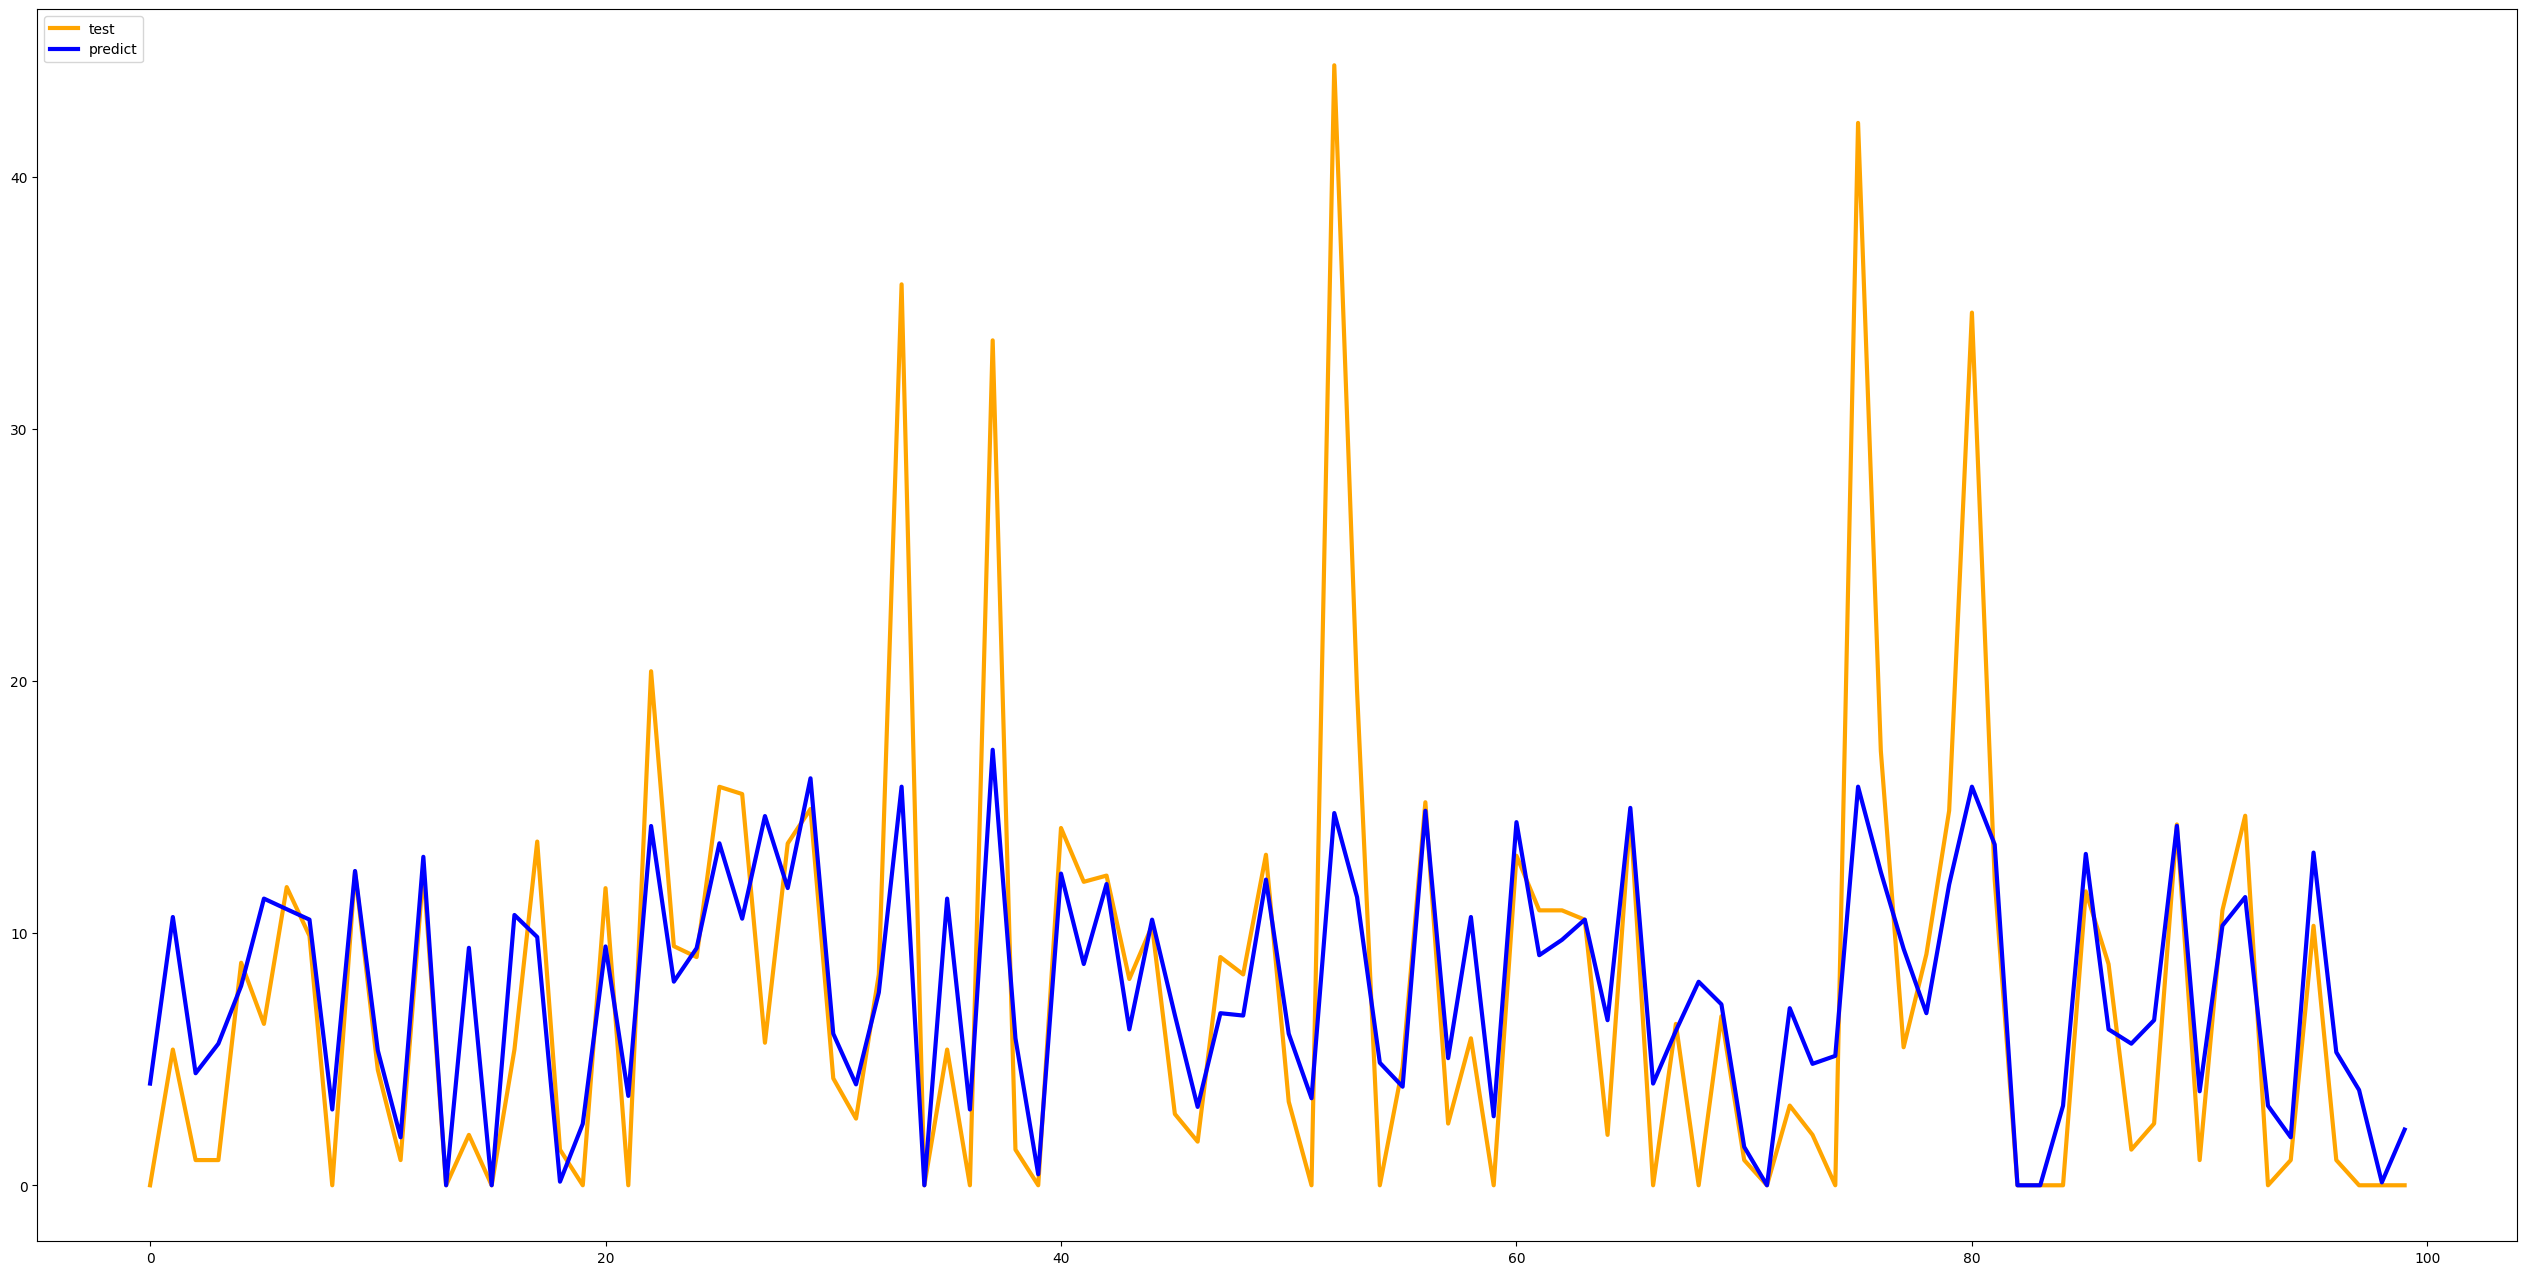

In [41]:
plt.figure(figsize=(32, 16))
plt.plot(range(0,len(X_test))[:100],y_test[:100], color="orange", linewidth=3 ,label = 'test')
plt.plot(range(0,len(X_test))[:100],pred[:100], color="blue", linewidth=3,label = 'predict')
plt.legend(loc="upper left")
plt.show()

In [42]:
#indexes = X_test.index.values
#index=indexes[98]

In [43]:
#X_test.loc[index]

In [44]:
#y_test[index],pred[98]

In [45]:
#metrics.mean_absolute_error(y_true, y_pred, *) -> Mean absolute error regression loss.
metrics.mean_absolute_error(y_test, pred)

2.6225954645693244

In [46]:
#metrics.mean_squared_error(y_true, y_pred, *) -> Mean squared error regression loss.
metrics.mean_squared_error(y_test, pred)

16.798996527724956

In [47]:
#metrics.mean_squared_error(y_true, pred, *) -> Mean squared error regression loss.
metrics.mean_squared_error(y_test, pred)**0.5

4.098657893472564

In [48]:
#metrics.mean_absolute_percentage_error(...) -> Mean absolute percentage error (MAPE) regression loss.
metrics.mean_absolute_percentage_error(y_test, pred)

2164571891215018.8

In [49]:
#metrics.r2_score(y_true, y_pred, *[, ...]) -> (coefficient of determination) regression score function.
metrics.r2_score(y_test, pred)

0.6564172342868

In [50]:
metrics.explained_variance_score(y_test, pred)

0.6638351532739699

In [51]:
from pyGRNN import GRNN

In [52]:
model_grnn = GRNN(sigma=5)

In [53]:
#dbfile = open('grnn_model.pickle', 'ab')
#pickle.dump(model_grnn, dbfile)                    
#dbfile.close()

In [54]:
#with (open("grnn_model.pickle", "rb")) as openfile:
    #model_grnn=pickle.load(openfile)

model_grnn.fit(X_train,y_train)

Executing warm start...
Warm start concluded. The optimum isotropic sigma is [0.03378073]


/Users/berkery/Projects/HepML/venv/lib/python3.10/site-packages/pyGRNN/GRNN.py:217: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if self.calibration is 'warm_start':
/Users/berkery/Projects/HepML/venv/lib/python3.10/site-packages/pyGRNN/GRNN.py:230: SyntaxWarning: "is" with a literal. Did you mean "=="?
  elif self.calibration is 'gradient_search':
/Users/berkery/Projects/HepML/venv/lib/python3.10/site-packages/pyGRNN/GRNN.py:217: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if self.calibration is 'warm_start':
/Users/berkery/Projects/HepML/venv/lib/python3.10/site-packages/pyGRNN/GRNN.py:230: SyntaxWarning: "is" with a literal. Did you mean "=="?
  elif self.calibration is 'gradient_search':
/Users/berkery/Projects/HepML/venv/lib/python3.10/site-packages/pyGRNN/GRNN.py:217: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if self.calibration is 'warm_start':
/Users/berkery/Projects/HepML/venv/lib/python3.10/site-packages/pyGRNN/GRNN.py:230: SyntaxWarnin

KeyboardInterrupt: 

In [ ]:
pred_grnn=model_grnn.predict(X_test)
pred_grnn

In [ ]:
plt.figure(figsize=(32, 16))
plt.plot(range(0,len(X_test))[:100],y_test[:100], color="orange", linewidth=3 ,label = 'test')
plt.plot(range(0,len(X_test))[:100],pred_grnn[:100], color="blue", linewidth=2,label = 'predict')
plt.legend(loc="upper left")
plt.show()

In [ ]:
#X_test['olcum'] = y_test
#X_test['tahmin'] = pred_grnn
X_test

In [ ]:
#metrics.mean_absolute_error(y_true, y_pred, *) -> Mean absolute error regression loss.
metrics.mean_absolute_error(y_test, pred_grnn)

In [ ]:
#metrics.mean_squared_error(y_true, y_pred, *) -> Mean squared error regression loss.
metrics.mean_squared_error(y_test, pred_grnn)

In [ ]:
#metrics.mean_squared_error(y_true, pred, *) -> Mean squared error regression loss.
metrics.mean_squared_error(y_test, pred_grnn)**0.5

In [ ]:
#metrics.mean_absolute_percentage_error(...) -> Mean absolute percentage error (MAPE) regression loss.
metrics.mean_absolute_percentage_error(y_test, pred_grnn)

In [ ]:
#metrics.r2_score(y_true, y_pred, *[, ...]) -> (coefficient of determination) regression score function.
metrics.r2_score(y_test, pred_grnn)

In [ ]:
metrics.explained_variance_score(y_test, pred_grnn)

In [ ]:
row = data.loc[data.index.values[0]]
row

In [ ]:
row = dict(row)
row

In [ ]:
row = {'CH4': 0.1,
 'Ar': 0.9,
 'N2': 0.0,
 'CO2': 0.0,
 'C': 0.02,
 'O': 0.0,
 'H': 0.8,
 'Detector_Size': 10.0,
 'Detector_Area': 100.0,
 'Cover_Size': 8.0,
 'Cover_Area': 64.0,
 'Cover_Area_Ratio': 0.64,
 'Voltage': 7000.0,
 'Time_Window': 15.0,
 'KV2': 49,
 'cs': 1.0}
df = pd.DataFrame.from_dict(row,orient='index').T
df

In [ ]:
model_grnn.predict(scalerModel.transform(df))